In [1]:
!pip install --user matplotlib
!pip install --user pandas
!pip install --user scipy
!pip install --user tqdm

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023

In [1]:
import matplotlib
%matplotlib inline

import _pickle as pickle
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scipy

from tqdm.notebook import tqdm

In [2]:
data_dir = "/home/chanb/scratch/hint_rl_results/logs/chanb/eval-math"
match_prefixes = [
    "local_eval-opsd",
]
all_evals = []
for match_prefix in match_prefixes:
    all_evals.extend(sorted([
        filename for filename in os.listdir(data_dir)
        if (
            os.path.isdir(os.path.join(data_dir, filename))
            and filename.startswith(match_prefix)
            # and len(os.listdir(os.path.join(data_dir, filename, "rollout/0"))) == 1853
        )
    ], key=lambda x: int(x.split("epoch")[1])))

In [3]:
all_evals

['local_eval-opsd-epoch0epochstep13globalstep13',
 'local_eval-opsd-epoch1epochstep13globalstep27']

In [4]:
all_results = dict()

In [5]:
n_samples = 8
k_sampless = [1, 2, 4, 8]

In [6]:
def pass_k(n_success, n_samples, k_samples):
    pass_k = (
        1 - scipy.special.comb(
            n_samples - n_success,
            k_samples,
            exact=False,
        ) / scipy.special.comb(n_samples, k_samples, exact=False)
    )
    return pass_k

# def pass_k(n_success, n_samples, k_samples):
#     pass_k = n_success / n_samples
#     return pass_k

In [7]:
agg_filename = "agg_eval-opsd-success_rate.pkl"
if os.path.isfile(agg_filename):
    all_results = pickle.load(open(agg_filename, "rb"))
else:
    all_results = {}
    for eval_name in tqdm(all_evals):
        curr_dir = os.path.join(data_dir, eval_name)
        pretrained_steps = 0
        total_train_steps = pretrained_steps + int(eval_name.split("globalstep")[1])
        key = total_train_steps

        curr_pass_k_results = []
        for sample_filename in os.listdir(os.path.join(curr_dir, "rollout/0")):
            sample_file = os.path.join(curr_dir, "rollout/0", sample_filename)
            sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
            curr_pass_k_results.append([
                pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
                for k_samples in k_sampless
            ])

        curr_pass_k_results = np.mean(curr_pass_k_results, axis=0)

        all_results[key] = curr_pass_k_results
    pickle.dump(all_results, open(agg_filename, "wb"))

In [8]:
baseline_dir = "/home/chanb/scratch/hint_rl_results/eval_results/per_model/local_eval-questa_no_hint"

baseline_pass_k_results = []
for sample_filename in os.listdir(os.path.join(baseline_dir, "rollout/0")):
    sample_file = os.path.join(baseline_dir, "rollout/0", sample_filename)
    sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
    baseline_pass_k_results.append([
        pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
        for k_samples in k_sampless
    ])

baseline_pass_k_results = np.mean(baseline_pass_k_results, axis=0)

In [9]:
baseline_pass_k_results

array([0.07332704, 0.12192583, 0.18859764, 0.26929304])

In [10]:
baseline_dir = "/home/chanb/scratch/hint_rl_results/eval_results/per_model/local_eval-questa_no_hint-paper_model"

baseline_pass_k_results_2 = []
for sample_filename in os.listdir(os.path.join(baseline_dir, "rollout/0")):
    sample_file = os.path.join(baseline_dir, "rollout/0", sample_filename)
    sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
    baseline_pass_k_results_2.append([
        pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
        for k_samples in k_sampless
    ])

baseline_pass_k_results_2 = np.mean(baseline_pass_k_results_2, axis=0)

In [11]:
baseline_pass_k_results_2

array([0.33007285, 0.41319096, 0.49127284, 0.56395035])

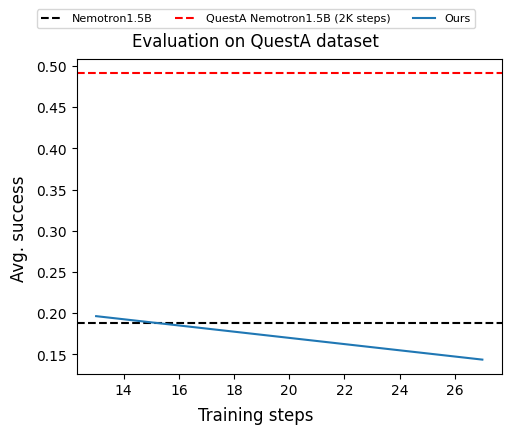

In [12]:
n_rows = 1
n_cols = 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 4.0 * n_rows), layout="constrained")

log_k = 2

x_range = sorted(all_results.keys())
y_vals = [
    all_results[key][log_k] for key in x_range
]

ax = axes
ax.axhline(
    baseline_pass_k_results[log_k],
    c="black",
    linestyle="--",
    label="Nemotron1.5B",
)
ax.axhline(
    baseline_pass_k_results_2[log_k],
    c="red",
    linestyle="--",
    label="QuestA Nemotron1.5B (2K steps)",
)
ax.plot(
    x_range,
    y_vals,
    label="Ours",
)
# ax.set_xticks(x_range)
# ax.set_ylim(-0.1, 1.1)

fig.suptitle("Evaluation on QuestA dataset")
# fig.supylabel("Pass@4")
fig.supylabel("Avg. success")
fig.supxlabel("Training steps")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

plt.show()

In [13]:
all_results

{13: array([0.07657658, 0.12660875, 0.19646075, 0.27702703]),
 27: array([0.05090028, 0.08834586, 0.14376731, 0.2132964 ])}